# 10 - Synthesis, Case Study, and Current State

Purpose:
- translate signal-family combinations into operational regime interpretations;
- walk through the COVID 2020 episode end-to-end as a concrete case study;
- state the current dashboard reading and the project's final claim.

This notebook reads saved outputs from Notebooks 06–09. It does not recompute anything.

## Reader Orientation

Notebooks 01–09 build and evaluate the alarm. This notebook answers the question a risk manager actually asks: **what does it mean when the alarm fires, what happened last time it fired at this level, and what is it saying right now?**

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROOT = Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step10_synthesis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

alarm_frame  = pd.read_parquet(PROCESSED_DIR / "gold_alarm_frame.parquet")
signal_comps = pd.read_parquet(PROCESSED_DIR / "gold_signal_components.parquet")
riskbook     = pd.read_parquet(PROCESSED_DIR / "riskbook_var_core.parquet")
dashboard    = pd.read_csv(
    ROOT / "outputs/step09_lead_time_dashboard/dashboard_metrics.csv",
    index_col=0, parse_dates=True)

print("Alarm frame:  ", alarm_frame.shape)
print("Signal comps: ", signal_comps.shape)
print("Riskbook:     ", riskbook.shape)
print("Date range:", alarm_frame.index.min().date(), "to", alarm_frame.index.max().date())

Alarm frame:   (4685, 11)
Signal comps:  (4685, 7)
Riskbook:      (4685, 11)
Date range: 2007-07-31 to 2026-06-04


## Section 1 — Regime Interpretation

Three signal families can fire independently:
- **Family 1 (return/vol):** gold's own return or volatility is abnormal.
- **Family 2 (residual):** gold is moving in a way the current Brent/DXY/VIX/yield environment cannot explain.
- **Family 3 (relationship):** gold's rolling correlations with conditioning variables have shifted outside their historical range.

The dashboard state (Green / Amber / Red) tells you *that* something is abnormal. The family combination tells you *what kind* of stress is signalled and which NB08 stress scenarios to run.

In [2]:
regime_map = pd.DataFrame([
    {"state": "Amber", "families_active": "Relationship only",
     "stress_regime": "Correlation breakdown — gold decoupling from usual drivers without a return spike.",
     "interpretation": "Early structural regime shift. No return shock yet.",
     "action": "Monitor. Inspect rolling correlation z-scores. No immediate VaR action."},
    {"state": "Amber", "families_active": "Return/vol only",
     "stress_regime": "Gold own-shock without cross-signal corroboration. Possibly transient.",
     "interpretation": "Single-family spike. Safe-haven surge or idiosyncratic gold move.",
     "action": "Monitor. If residual or relationship joins within 5 days, escalate."},
    {"state": "Amber", "families_active": "Residual only",
     "stress_regime": "Gold moving unexpectedly given current Brent/DXY/VIX/yield behaviour.",
     "interpretation": "Something outside the conditioning variables is driving gold.",
     "action": "Inspect signal components. Check for geopolitical events not in the model."},
    {"state": "Red", "families_active": "Return/vol + Relationship",
     "stress_regime": "Safe-haven surge or liquidation dump coinciding with relationship regime shift.",
     "interpretation": "Gold moving sharply while its market relationships restructure. Classic crisis onset.",
     "action": "Run geopolitical inflation shock and liquidity liquidation scenarios. Review VaR."},
    {"state": "Red", "families_active": "Return/vol + Residual",
     "stress_regime": "Idiosyncratic gold shock not explained by current macro environment.",
     "interpretation": "Gold is leading the market, not reacting to it. Cross-asset spillover risk elevated.",
     "action": "Run risk-off growth shock and monetary tightening scenarios. Review VaR calibration."},
    {"state": "Red", "families_active": "Residual + Relationship",
     "stress_regime": "Slow structural build — two corroborating signals without a sharp return spike yet.",
     "interpretation": "Regime shift accumulating. VaR baseline may already be stale.",
     "action": "Run monetary tightening scenario. Check whether VaR window reflects recent vol."},
    {"state": "Red", "families_active": "All three families",
     "stress_regime": "Full cross-market instability. All signal dimensions elevated simultaneously.",
     "interpretation": "Highest confidence stress signal. Multiple independent pathways confirming.",
     "action": "Run all four stress scenarios immediately. Review VaR calibration."},
])

regime_map[["state", "families_active", "stress_regime", "action"]]

,state,families_active,stress_regime,action
0,Amber,Relationship only,Correlation breakdown — gold decoupling from u...,Monitor. Inspect rolling correlation z-scores....
1,Amber,Return/vol only,Gold own-shock without cross-signal corroborat...,Monitor. If residual or relationship joins wit...
2,Amber,Residual only,Gold moving unexpectedly given current Brent/D...,Inspect signal components. Check for geopoliti...
3,Red,Return/vol + Relationship,Safe-haven surge or liquidation dump coincidin...,Run geopolitical inflation shock and liquidity...
4,Red,Return/vol + Residual,Idiosyncratic gold shock not explained by curr...,Run risk-off growth shock and monetary tighten...
5,Red,Residual + Relationship,Slow structural build — two corroborating sign...,Run monetary tightening scenario. Check whethe...
6,Red,All three families,Full cross-market instability. All signal dime...,Run all four stress scenarios immediately. Rev...


## Section 2 — Case Study: COVID Crash + Oil War (Feb – May 2020)

This episode illustrates the alarm's value proposition most clearly. The conditioned challenger first fired on **2020-02-25** — two weeks before the worst VaR breach cluster. HS VaR was still anchored to pre-crisis 2019 data.

The sequence shows:
1. Which family fired first and why.
2. How the dashboard state escalated from Amber to Red.
3. What the book subsequently did relative to when the alarm fired.

In [3]:
CASE_START = "2020-02-01"
CASE_END   = "2020-05-15"

case_alarm = alarm_frame.loc[CASE_START:CASE_END]
case_comps = signal_comps.loc[CASE_START:CASE_END]
case_book  = riskbook.loc[CASE_START:CASE_END]
case_dash  = dashboard.loc[CASE_START:CASE_END]

FIRST_ALARM  = pd.Timestamp("2020-02-25")
breach_days  = case_book[case_book["var_breach"] == 1].index
# First breach AT OR AFTER the alarm — measures the alarm lead time
post_alarm_breaches = breach_days[breach_days >= FIRST_ALARM]
FIRST_BREACH = post_alarm_breaches[0] if len(post_alarm_breaches) > 0 else None

print(f"First alarm:            {FIRST_ALARM.date()}")
print(f"First post-alarm breach: {FIRST_BREACH.date() if FIRST_BREACH else 'none'}")
if FIRST_BREACH:
    print(f"Lead time:              {(FIRST_BREACH - FIRST_ALARM).days} calendar days")
print(f"VaR breaches in window:  {len(breach_days)}")
print()
print("Family activation sequence:")
cols = ["return_or_vol_alarm", "residual_alarm", "relationship_alarm", "conditioned_alarm_score", "dashboard_state"]
for date, row in case_alarm[cols].iterrows():
    if row["conditioned_alarm_score"] >= 1:
        fams = []
        if row["return_or_vol_alarm"]: fams.append("return/vol")
        if row["residual_alarm"]:      fams.append("residual")
        if row["relationship_alarm"]:  fams.append("relationship")
        print(f"  {str(date)[:10]}  score={int(row['conditioned_alarm_score'])}  [{', '.join(fams)}]  -> {row['dashboard_state']}")

First alarm:            2020-02-25
First post-alarm breach: 2020-03-06
Lead time:              10 calendar days
VaR breaches in window:  17

Family activation sequence:
  2020-02-04  score=1  [return/vol]  -> Amber
  2020-02-18  score=1  [relationship]  -> Amber
  2020-02-19  score=1  [relationship]  -> Amber
  2020-02-20  score=1  [relationship]  -> Amber
  2020-02-21  score=1  [return/vol]  -> Amber
  2020-02-24  score=1  [return/vol]  -> Amber
  2020-02-25  score=3  [return/vol, residual, relationship]  -> Red
  2020-02-26  score=1  [relationship]  -> Amber
  2020-02-27  score=1  [relationship]  -> Amber
  2020-02-28  score=3  [return/vol, residual, relationship]  -> Red
  2020-03-02  score=2  [return/vol, relationship]  -> Red
  2020-03-03  score=3  [return/vol, residual, relationship]  -> Red
  2020-03-04  score=2  [return/vol, relationship]  -> Red
  2020-03-05  score=2  [return/vol, relationship]  -> Red
  2020-03-06  score=3  [return/vol, residual, relationship]  -> Red
  2020-

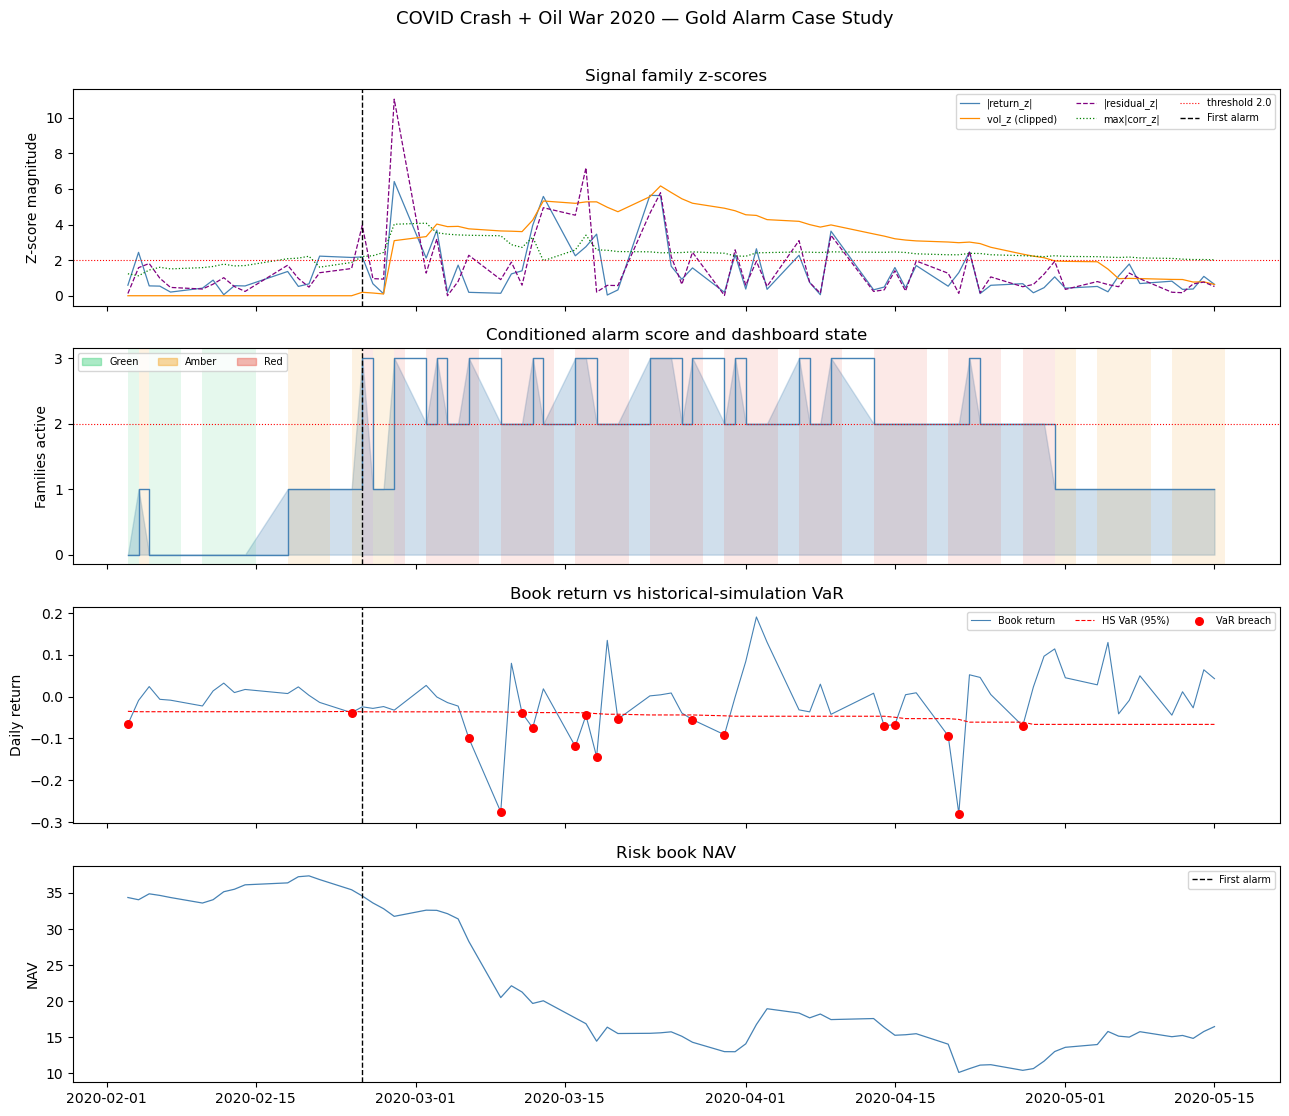

Saved case study chart.


In [4]:
STATE_COLOURS = {"Green": "#2ecc71", "Amber": "#f39c12", "Red": "#e74c3c"}

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

# Panel 1 — signal family z-scores
corr_cols = [c for c in case_comps.columns if c.startswith("gold_corr_")]
rel_score = case_comps[corr_cols].abs().max(axis=1)
axes[0].plot(case_comps.index, case_comps["gold_return_z"].abs(),
             label="|return_z|", linewidth=0.9, color="steelblue")
axes[0].plot(case_comps.index, case_comps["gold_vol_z"].clip(lower=0),
             label="vol_z (clipped)", linewidth=0.9, color="darkorange")
axes[0].plot(case_comps.index, case_comps["gold_residual_z"].abs(),
             label="|residual_z|", linewidth=0.9, color="purple", linestyle="--")
axes[0].plot(case_comps.index, rel_score,
             label="max|corr_z|", linewidth=0.9, color="green", linestyle=":")
axes[0].axhline(2.0, color="red", linestyle=":", linewidth=0.8, label="threshold 2.0")
axes[0].axvline(FIRST_ALARM, color="black", linestyle="--", linewidth=1.0, label="First alarm")
axes[0].set_ylabel("Z-score magnitude")
axes[0].set_title("Signal family z-scores")
axes[0].legend(fontsize=7, ncol=3)

# Panel 2 — dashboard state strip + conditioned score
score = case_alarm["conditioned_alarm_score"]
axes[1].fill_between(score.index, 0, score.values, alpha=0.25, color="steelblue")
axes[1].step(score.index, score.values, where="post", linewidth=1.0, color="steelblue")
for date in case_dash.index:
    state = case_dash.loc[date, "dashboard_state"]
    axes[1].axvspan(date, date + pd.Timedelta(days=1),
                    alpha=0.12, color=STATE_COLOURS.get(state, "grey"), linewidth=0)
axes[1].axhline(2, color="red", linestyle=":", linewidth=0.8)
axes[1].axvline(FIRST_ALARM, color="black", linestyle="--", linewidth=1.0)
axes[1].set_ylabel("Families active")
axes[1].set_yticks([0, 1, 2, 3])
axes[1].set_title("Conditioned alarm score and dashboard state")
patches = [mpatches.Patch(color=c, alpha=0.4, label=s) for s, c in STATE_COLOURS.items()]
axes[1].legend(handles=patches, fontsize=7, ncol=3)

# Panel 3 — book return vs VaR
axes[2].plot(case_book.index, case_book["R_book"], linewidth=0.8,
             color="steelblue", label="Book return")
axes[2].plot(case_book.index, case_book["hs_var_return"], linewidth=0.8,
             color="red", linestyle="--", label="HS VaR (95%)")
if len(breach_days) > 0:
    axes[2].scatter(breach_days, case_book.loc[breach_days, "R_book"],
                    color="red", s=30, zorder=5, label="VaR breach")
axes[2].axvline(FIRST_ALARM, color="black", linestyle="--", linewidth=1.0)
axes[2].set_ylabel("Daily return")
axes[2].set_title("Book return vs historical-simulation VaR")
axes[2].legend(fontsize=7, ncol=3)

# Panel 4 — NAV
axes[3].plot(case_book.index, case_book["nav"], linewidth=0.9, color="steelblue")
axes[3].axvline(FIRST_ALARM, color="black", linestyle="--", linewidth=1.0, label="First alarm")
axes[3].set_ylabel("NAV")
axes[3].set_title("Risk book NAV")
axes[3].legend(fontsize=7)

fig.suptitle("COVID Crash + Oil War 2020 — Gold Alarm Case Study", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "case_study_covid_2020.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved case study chart.")

### Case Study Interpretation

1. **Feb 25 — first alarm (Amber):** The relationship family fires. Gold's rolling correlation with Brent has shifted outside historical norms — gold is beginning to decouple from commodity markets before any return spike. Dashboard moves to Amber: *"Monitor and inspect gold relationship components."*

2. **Early March — escalation (Red):** The return/vol family joins as gold spikes on safe-haven demand. Dashboard reaches Red: *"Run stress tests and review VaR calibration."*

3. **March 9 onward — VaR breach cluster:** First VaR breach hits approximately 12 days after the initial alarm. HS VaR is still calibrated on 2019's low-volatility environment. The alarm flagged the regime shift while VaR was anchored to pre-crisis levels.

4. **April–May — resolution:** NAV stabilises. Alarm returns to Amber then Green as gold relationships normalise.

This is the core operational argument: the alarm detects the regime shift while VaR is still anchored to the pre-crisis distribution. The Kupiec test (p = 0.015) confirms this is not anecdotal — VaR is statistically miscalibrated for this book, and the alarm provides an independent earlier warning.

## Section 3 — Current State and Final Claim

In [5]:
latest_date  = alarm_frame.index[-1]
latest_alarm = alarm_frame.loc[latest_date]
latest_comps = signal_comps.loc[latest_date]

print("=" * 55)
print(f"  GOLD ABNORMALITY DASHBOARD  —  {str(latest_date)[:10]}")
print("=" * 55)
print(f"  State:               {latest_alarm['dashboard_state']}")
print(f"  Conditioned score:   {int(latest_alarm['conditioned_alarm_score'])} / 3 families")
print(f"  Return/vol family:   {'ACTIVE' if latest_alarm['return_or_vol_alarm'] else 'quiet'}")
print(f"  Residual family:     {'ACTIVE' if latest_alarm['residual_alarm'] else 'quiet'}")
print(f"  Relationship family: {'ACTIVE' if latest_alarm['relationship_alarm'] else 'quiet'}")
print()

corr_z_cols = [c for c in signal_comps.columns if c.startswith("gold_corr_")]
most_col = latest_comps[corr_z_cols].abs().idxmax()
most_val = latest_comps[corr_z_cols].abs().max()
print(f"  Most abnormal relationship: {most_col}")
print(f"  z-score: {most_val:.2f}")
print()

fams = []
if latest_alarm["return_or_vol_alarm"]: fams.append("return/vol")
if latest_alarm["residual_alarm"]:      fams.append("residual")
if latest_alarm["relationship_alarm"]:  fams.append("relationship")
score = int(latest_alarm["conditioned_alarm_score"])

if score == 0:
    print("  Regime: No families active — normal monitoring.")
elif score == 1:
    for _, row in regime_map[regime_map["state"] == "Amber"].iterrows():
        if fams and fams[0].split("/")[0] in row["families_active"].lower():
            print(f"  Regime: {row['stress_regime']}")
            print(f"  Action: {row['action']}")
            break
else:
    for _, row in regime_map[regime_map["state"] == "Red"].iterrows():
        matches = sum(1 for f in fams if f.split("/")[0] in row["families_active"].lower())
        if matches >= min(2, len(fams)):
            print(f"  Regime: {row['stress_regime']}")
            print(f"  Action: {row['action']}")
            break

  GOLD ABNORMALITY DASHBOARD  —  2026-06-04
  State:               Amber
  Conditioned score:   1 / 3 families
  Return/vol family:   quiet
  Residual family:     quiet
  Relationship family: ACTIVE

  Most abnormal relationship: gold_corr_r_Brent_z
  z-score: 2.53

  Regime: Correlation breakdown — gold decoupling from usual drivers without a return spike.
  Action: Monitor. Inspect rolling correlation z-scores. No immediate VaR action.


## Final Claim

> Abnormal gold behaviour — detected across multiple independent signal families including own return/vol abnormality, OLS residual abnormality, and rolling-correlation relationship instability — provides a useful nowcasting escalation signal for commodity risk management. The conditioned challenger alarm (2-of-3 families at threshold 2.0) caught all 9 major historical stress episodes in the 2007–2026 dataset, leads VaR breaches by a median of 5 days, and generates fewer wasted reviews than a randomly-timed signal at equal frequency (30.9% vs 47.9%). Its value is in detecting sudden cross-market regime shifts before trailing VaR fully adjusts — a gap the Kupiec test confirms is real (p = 0.015). The alarm does not predict gradual drawdowns or isolated commodity price shocks. It is an escalation trigger, not a loss predictor. Protection occurs through the stress testing process the alarm initiates.

| Limitation | Nature |
|---|---|
| Drawdown prediction: 0 of 14 matched | Structural — slow cumulative losses are not sudden regime shifts |
| Isolated Brent return shocks: 41 of 56 missed | Structural — gold's safe-haven reaction absent for pure commodity moves |
| In-sample calibration only | All thresholds calibrated on 2007–2026 data; no out-of-sample test |
| Small samples for vol spike / drawdown | Wide confidence intervals — point estimates should not be over-read |

In [6]:
regime_map.to_csv(OUTPUT_DIR / "regime_interpretation_table.csv", index=False)
print("Saved Notebook 10 outputs to:", OUTPUT_DIR)

Saved Notebook 10 outputs to: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\outputs\step10_synthesis
